In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv('cleaned_diabetes.csv')

In [3]:
print(df.head())

   race  gender  age  admission_type_id  discharge_disposition_id  \
0     2       0    0                  6                        25   
1     2       0    1                  1                         1   
2     0       0    2                  1                         1   
3     2       1    3                  1                         1   
4     2       1    4                  1                         1   

   admission_source_id  time_in_hospital  num_lab_procedures  num_procedures  \
0                    1                 1                  41               0   
1                    7                 3                  59               0   
2                    7                 2                  11               5   
3                    7                 2                  44               1   
4                    7                 1                  51               0   

   num_medications  ...  citoglipton  insulin  glyburide.metformin  \
0                1  ...           

In [4]:
print("Generating Exploratory Data Analysis Visualizations...\n")
sns.set_theme(style="whitegrid")

Generating Exploratory Data Analysis Visualizations...



C:\Users\User\AppData\Local\Temp\ipykernel_23876\3633452372.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='readmitted', data=df, palette='viridis')


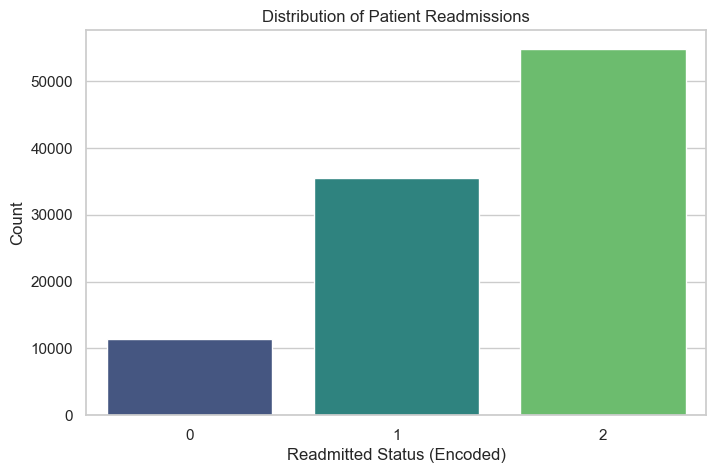

In [6]:
# Visualization 1: Countplot of the Target Variable (readmitted)
plt.figure(figsize=(8, 5))
sns.countplot(x='readmitted', data=df, palette='viridis')
plt.title('Distribution of Patient Readmissions')
plt.xlabel('Readmitted Status (Encoded)')
plt.ylabel('Count')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_23876\3335589728.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='readmitted', y='time_in_hospital', data=df, palette='Set2')


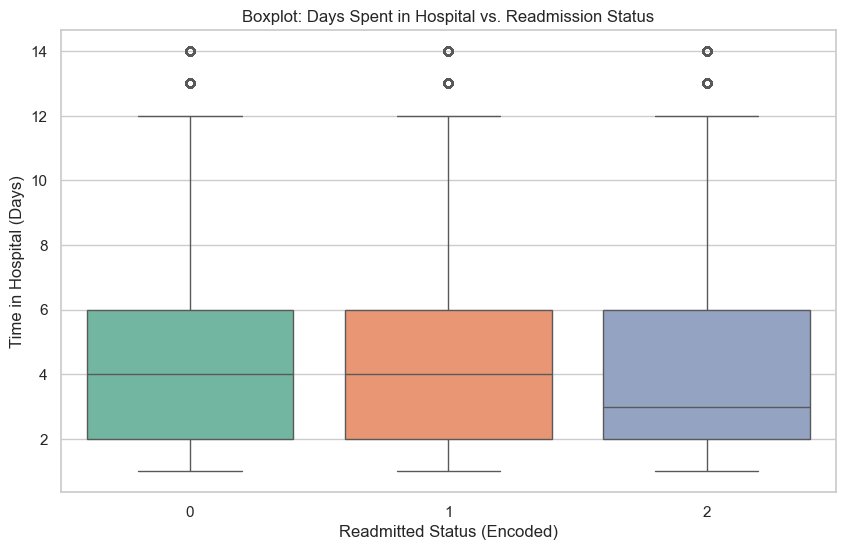

In [7]:
# Visualization 2: Boxplot to find patterns (Time in Hospital vs Readmission)
plt.figure(figsize=(10, 6))
sns.boxplot(x='readmitted', y='time_in_hospital', data=df, palette='Set2')
plt.title('Boxplot: Days Spent in Hospital vs. Readmission Status')
plt.xlabel('Readmitted Status (Encoded)')
plt.ylabel('Time in Hospital (Days)')
plt.show()

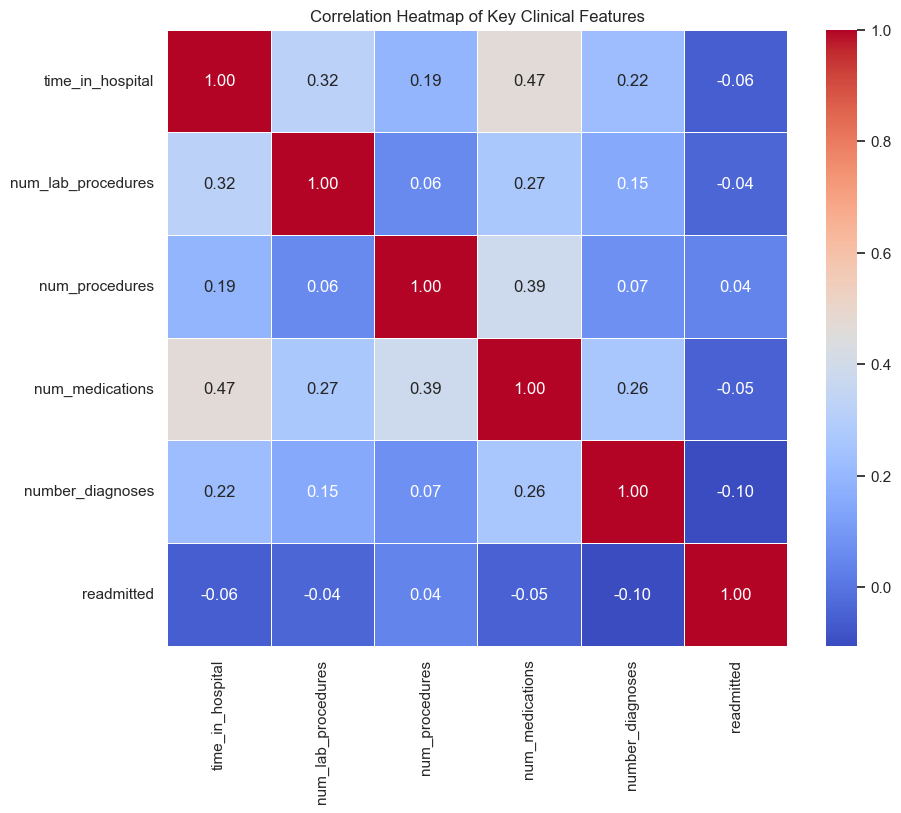

In [8]:
# Selecting a subset of continuous/numerical features for a cleaner heatmap
cols_for_heatmap = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 
                    'num_medications', 'number_diagnoses', 'readmitted']
plt.figure(figsize=(10, 8))
correlation_matrix = df[cols_for_heatmap].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Key Clinical Features')
plt.show()

In [10]:
#IMPLEMENT ALGORITHM 2 (Decision Tree)
print("\nPreparing data for Decision Tree modeling...")
# Separate features (X) and target variable (y)
X = df.drop('readmitted', axis=1)
y = df['readmitted']
# Split data: 80% for training and 20% for testing (same as Member 1 for fair comparison)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
print("Training Decision Tree Model... Please wait.")
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_predictions)
print(f"Decision Tree Model Accuracy: {dt_accuracy:.4f}")


Preparing data for Decision Tree modeling...
Training Decision Tree Model... Please wait.
Decision Tree Model Accuracy: 0.5743
